# Figure assembly notebook

This notebook assembles manuscript-ready figures from completed evaluation outputs.
It uses shared plotting helpers, and saves exports into the configured `outputs.directory`.

## Required inputs
- `config.yaml` to resolve the evaluation output root.
- Parquet outputs generated by the synthetic, sparsification, stability, and Boston workflows.

## Generated outputs
- Inline previews for quick review.
- Publication-ready exports under `results/figures/` (resolved from `config.yaml`).


## Workflow

Run the notebook from top to bottom after refreshing the evaluation results. Each
section loads only the tables it needs and ends by previewing one figure:

1. Sparsification compatibility surfaces (`Fig1`)
2. Synthetic performance summaries (`Fig2`, `Fig3`)
3. Temporal stability diagnostics (`Fig4`)
4. Boston cluster descriptives (`Fig5`)


In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import numpy as np
import pandas as pd
import seaborn as sns

from config import load_config, outputs_root, project_root
from plotting import (
    PLOS_WIDTHS_CM,
    add_panel_labels,
    cm_to_inch,
    save_plos_figure,
    set_plos_theme,
)

In [2]:
PROJECT_ROOT = project_root()
CONFIG = load_config()
RESULTS_ROOT = outputs_root(CONFIG)
FIGURE_OUTPUT_DIR = RESULTS_ROOT / "figures"
SAVE_FIGURES = True


def read_result_table(*parts: str) -> pd.DataFrame:
    return pd.read_parquet(RESULTS_ROOT.joinpath(*parts))


def export_figure(fig: plt.Figure, stem: str, **kwargs) -> dict[str, Path]:
    if not SAVE_FIGURES:
        return {}
    return save_plos_figure(fig, stem, outdir=FIGURE_OUTPUT_DIR, **kwargs)


set_plos_theme()

print(f"Project root: {PROJECT_ROOT}")
print(f"Results root: {RESULTS_ROOT}")
print(f"Figure output directory: {FIGURE_OUTPUT_DIR}")
print(f"Save figures: {SAVE_FIGURES}")


Project root: /Users/ydnkka/Desktop/Phd Project/projects/epilink/evaluation
Results root: /Users/ydnkka/Desktop/Phd Project/projects/epilink/evaluation/results
Figure output directory: /Users/ydnkka/Desktop/Phd Project/projects/epilink/evaluation/results/figures
Save figures: True


## Figure 1 · Compatibility surfaces

In [3]:
surfaces = read_result_table("sparsification", "score_surfaces.parquet")

SURFACE_PANELS = ("compatibility_deterministic", "compatibility_stochastic")


def surface_matrix(surface_frame: pd.DataFrame, score: str) -> pd.DataFrame:
    """Pivot a long surface table into a days-by-SNP matrix."""
    return (
        surface_frame.pivot(index="days", columns="snp", values=score)
        .sort_index()
        .sort_index(axis=1)
    )


def add_surface_panel(
    ax: plt.Axes,
    surface_frame: pd.DataFrame,
    score: str,
):
    pivot = surface_matrix(surface_frame, score)
    x_values = pivot.columns.to_numpy(dtype=float)
    y_values = pivot.index.to_numpy(dtype=float)
    z_values = pivot.to_numpy(dtype=float)

    filled = ax.contourf(
        x_values,
        y_values,
        z_values,
        levels=np.linspace(0.0, 1.0, 11),
        cmap="mako",
        antialiased=True,
    )
    ax.xaxis.set_major_locator(MultipleLocator(3))
    ax.yaxis.set_major_locator(MultipleLocator(3))
    return filled

Saved PDF: /Users/ydnkka/Desktop/Phd Project/projects/epilink/evaluation/results/figures/Fig1.pdf
Saved TIFF: /Users/ydnkka/Desktop/Phd Project/projects/epilink/evaluation/results/figures/Fig1.tif


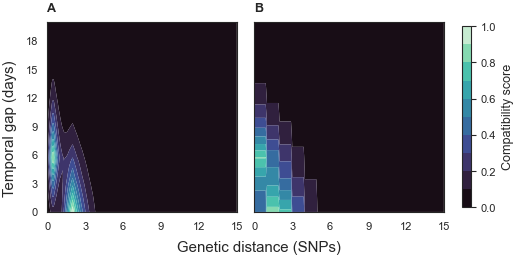

In [4]:
fig1, axes1 = plt.subplots(
    1,
    2,
    figsize=(
        cm_to_inch(PLOS_WIDTHS_CM["text_column"]),
        cm_to_inch(PLOS_WIDTHS_CM["text_column"]) * 0.5,
    ),
    sharex=True,
    sharey=True,
    constrained_layout=True,
    gridspec_kw={"hspace": 0.1},
)
axes1 = np.atleast_1d(axes1).flatten()

filled = None
for ax, score in zip(axes1, SURFACE_PANELS):
    filled = add_surface_panel(ax, surfaces, score)

if filled is None:
    raise RuntimeError("No surface panels were drawn.")

colorbar = fig1.colorbar(
    filled,
    ax=axes1,
    location="right",
    shrink=0.95,
    pad=0.03,
)
colorbar.set_label("Compatibility score")

fig1.supxlabel("Genetic distance (SNPs)")
fig1.supylabel("Temporal gap (days)")
add_panel_labels(list(axes1))
export_figure(fig1, "Fig1")
plt.show()

## Figures 2–3 · Synthetic sensitivity results

In [12]:
results = read_result_table("synthetic", "results.parquet").copy()

SCENARIO_LABELS = {
    "baseline": "Baseline",
    "incubation_mean_0.75": "Inc mean ↓25%",
    "incubation_mean_1.25": "Inc mean ↑25%",
    "incubation_cv_0.75": "Inc CV ↓25%",
    "incubation_cv_1.25": "Inc CV ↑25%",
    "testing_delay_mean_0.75": "Test mean ↓25%",
    "testing_delay_mean_1.25": "Test mean ↑25%",
    "testing_delay_cv_0.75": "Test CV ↓25%",
    "testing_delay_cv_1.25": "Test CV ↑25%",
    "substitution_rate_0.75": "Clock rate ↓25%",
    "substitution_rate_1.25": "Clock rate ↑25%",
    "relaxation_0.00": "Strict clock",
    "relaxation_1.25": "Relaxation ↑25%",
}
SCENARIO_ORDER = [
    "incubation_mean_0.75",
    "incubation_mean_1.25",
    "incubation_cv_0.75",
    "incubation_cv_1.25",
    "testing_delay_mean_0.75",
    "testing_delay_mean_1.25",
    "testing_delay_cv_0.75",
    "testing_delay_cv_1.25",
    "substitution_rate_0.75",
    "substitution_rate_1.25",
    "relaxation_0.00",
    "relaxation_1.25",
]
CONDITION_LABELS = {
    "matched": "Matched",
    "generation_varied_inference_fixed": "Mismatched",
}
CONDITION_ORDER = list(CONDITION_LABELS.values())
METRIC_PANELS = [
    ("ap", "Average precision"),
    ("best_f1", "Best F1 score"),
    ("mean_stability", "Partition stability (mean)"),
    ("std_stability", "Partition stability (SD)"),
]
LOSS_PANELS = [
    ("ap_loss", "Matched"),
    ("ap_loss", "Mismatched"),
    ("f1_loss", "Matched"),
    ("f1_loss", "Mismatched"),
]

results["condition"] = (
    results["condition"].map(CONDITION_LABELS).fillna(results["condition"])
)
MODEL_ORDER = list(results["model"].drop_duplicates())


def plot_metric_panel(
    ax: plt.Axes,
    df: pd.DataFrame,
    metric: str,
    title: str,
) -> None:
    sns.pointplot(
        data=df,
        x="model",
        y=metric,
        hue="condition",
        order=MODEL_ORDER,
        hue_order=CONDITION_ORDER,
        dodge=True,
        errorbar=("ci", 95),
        ax=ax,
    )
    ax.set_xlabel("")
    ax.set_ylabel(title)
    ax.set_ylim(0, 1)


def make_heatmap(
    df: pd.DataFrame,
    value_col: str,
    ax: plt.Axes,
    *,
    condition_label: str,
) -> None:
    plot_df = df.loc[df["condition"] == condition_label].copy()
    plot_df = plot_df.loc[plot_df["scenario"] != "baseline"].copy()

    heatmap = (
        plot_df.pivot_table(
            index="scenario",
            columns="model",
            values=value_col,
            aggfunc="mean",
        )
        .reindex(index=SCENARIO_ORDER, columns=MODEL_ORDER)
    )

    sns.heatmap(
        heatmap,
        ax=ax,
        cmap="vlag",
        annot=True,
        fmt=".2f",
        annot_kws={"size": 7},
        linewidths=0.2,
        linecolor="white",
        cbar=False,
        vmin=-1,
        vmax=1,
    )
    ax.set_yticklabels(
        [SCENARIO_LABELS.get(t.get_text(), t.get_text()) for t in ax.get_yticklabels()],
        rotation=0,
    )
    for y in [4, 8]:
        ax.axhline(y, color="black", linewidth=1)
    ax.set_xlabel("")
    ax.set_ylabel("")

In [13]:
baseline = results.loc[(results["scenario"] == "baseline")
                       & (results["condition"] == "Matched")]

for data in baseline.to_dict(orient="records"):
    print(
        f"\t{data["model"]}: "
        f"AP={data["ap"]:.3f}, "
        f"F1={data["best_f1"]:.3f}, "
        f"Mean={data["mean_stability"]:.3f} "
        f"SD={data["std_stability"]:.3f} "
    )

	EDD: AP=0.300, F1=0.556, Mean=0.871 SD=0.077 
	EDS: AP=0.090, F1=0.476, Mean=0.834 SD=0.090 
	ESD: AP=0.469, F1=0.601, Mean=0.851 SD=0.073 
	ESS: AP=0.190, F1=0.534, Mean=0.830 SD=0.079 
	LD: AP=0.568, F1=0.688, Mean=0.895 SD=0.044 
	LS: AP=0.275, F1=0.570, Mean=0.927 SD=0.094 


Saved PDF: /Users/ydnkka/Desktop/Phd Project/projects/epilink/evaluation/results/figures/Fig2.pdf
Saved TIFF: /Users/ydnkka/Desktop/Phd Project/projects/epilink/evaluation/results/figures/Fig2.tif


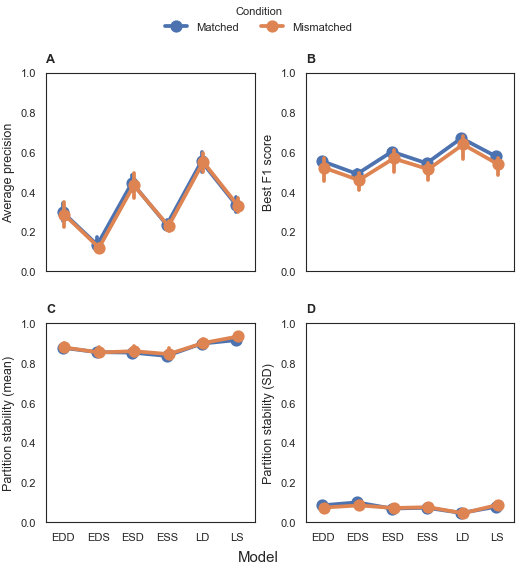

In [7]:
fig2, axes2 = plt.subplots(
    2,
    2,
    figsize=(
        cm_to_inch(PLOS_WIDTHS_CM["text_column"]),
        cm_to_inch(PLOS_WIDTHS_CM["text_column"]),
    ),
    sharex=True,
    constrained_layout=True,
    gridspec_kw={"hspace": 0.1},
)
axes2 = axes2.flatten()

for ax, (metric, title) in zip(axes2, METRIC_PANELS):
    plot_metric_panel(ax, results, metric=metric, title=title)

handles, labels = axes2[0].get_legend_handles_labels()
for ax in axes2:
    if ax.legend_ is not None:
        ax.legend_.remove()

fig2.legend(
    handles,
    labels,
    title="Condition",
    loc="upper center",
    bbox_to_anchor=(0.5, 1.1),
    ncol=2,
)
fig2.supxlabel("Model")
add_panel_labels(list(axes2), size="medium")
export_figure(fig2, "Fig2")
plt.show()


Saved PDF: /Users/ydnkka/Desktop/Phd Project/projects/epilink/evaluation/results/figures/Fig3.pdf
Saved TIFF: /Users/ydnkka/Desktop/Phd Project/projects/epilink/evaluation/results/figures/Fig3.tif


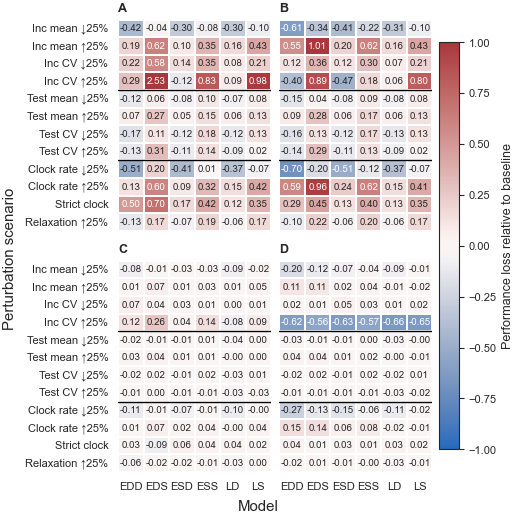

In [14]:
fig3, axes3 = plt.subplots(
    2,
    2,
    figsize=(
        cm_to_inch(PLOS_WIDTHS_CM["text_column"]),
        cm_to_inch(PLOS_WIDTHS_CM["text_column"]),
    ),
    sharex=True,
    constrained_layout=True,
    gridspec_kw={"hspace": 0.05},
)
axes3 = axes3.flatten()

for ax, (metric, condition_label) in zip(axes3, LOSS_PANELS):
    make_heatmap(
        results,
        metric,
        ax=ax,
        condition_label=condition_label,
    )

scalar_mappable = mpl.cm.ScalarMappable(
    norm=mpl.colors.Normalize(vmin=-1, vmax=1),
    cmap="vlag",
)
scalar_mappable.set_array([])

colorbar = fig3.colorbar(
    scalar_mappable,
    ax=axes3,
    location="right",
    shrink=0.9,
    pad=0.02,
)
colorbar.set_label("Performance loss relative to baseline")

axes3[0].tick_params(axis="y", labelleft=True)
axes3[1].tick_params(axis="y", labelleft=False)
axes3[2].tick_params(axis="y", labelleft=True)
axes3[3].tick_params(axis="y", labelleft=False)

fig3.supylabel("Perturbation scenario")
fig3.supxlabel("Model")
add_panel_labels(list(axes3), y=1.08)
export_figure(fig3, "Fig3")
plt.show()


In [16]:
data = results.loc[results["scenario"] != "baseline"]
data.groupby(["model", "condition"])[["ap_loss", "f1_loss"]].mean()

ap_loss   f1_loss
model condition                     
EDD   Matched    -0.004853 -0.003795
      Mismatched -0.052126 -0.067955
EDS   Matched     0.510006  0.030304
      Mismatched  0.340293 -0.040281
ESD   Matched    -0.054426  0.001718
      Mismatched -0.084086 -0.060018
ESS   Matched     0.246528  0.020291
      Mismatched  0.211347 -0.040754
LD    Matched    -0.028841 -0.028937
      Mismatched -0.034434 -0.079224
LS    Matched     0.228672  0.013850
      Mismatched  0.214186 -0.059231

## Figure 4 · Temporal stability across epidemic weeks

In [40]:
stability_frames = {
    "EDD": read_result_table("stability", "temporal_stability_EDD.parquet"),
    "EDS": read_result_table("stability", "temporal_stability_EDS.parquet"),
    "ESD": read_result_table("stability", "temporal_stability_ESD.parquet"),
    "ESS": read_result_table("stability", "temporal_stability_ESS.parquet"),
    "LD": read_result_table("stability", "temporal_stability_LD.parquet"),
    "LS": read_result_table("stability", "temporal_stability_LS.parquet"),
}
STABILITY_MARKERS = {
    "forward": "^",
    "backward": "*",
    "jaccard": "d",
}
STABILITY_COLORS = {
    "forward": "#0072B2",
    "backward": "#D55E00",
    "jaccard": "#CC79A7",
}
STABILITY_LABELS = {
    "forward": "Forward",
    "backward": "Backward",
    "jaccard": "Jaccard",
}


def plot_stability_panel(
    df: pd.DataFrame,
    ax: plt.Axes,
    model: str,
) -> None:
    for metric in ("forward", "backward", "jaccard"):
        sns.lineplot(
            data=df,
            x="t1",
            y=metric,
            color=STABILITY_COLORS[metric],
            marker=STABILITY_MARKERS[metric],
            ax=ax,
            label=STABILITY_LABELS[metric],
        )
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_ylim(0, 1.05)

    ax.text(
        0.98, 0, model, transform=ax.transAxes,
        ha="right",va="bottom")


Saved PDF: /Users/ydnkka/Desktop/Phd Project/projects/epilink/evaluation/results/figures/Fig4.pdf
Saved TIFF: /Users/ydnkka/Desktop/Phd Project/projects/epilink/evaluation/results/figures/Fig4.tif


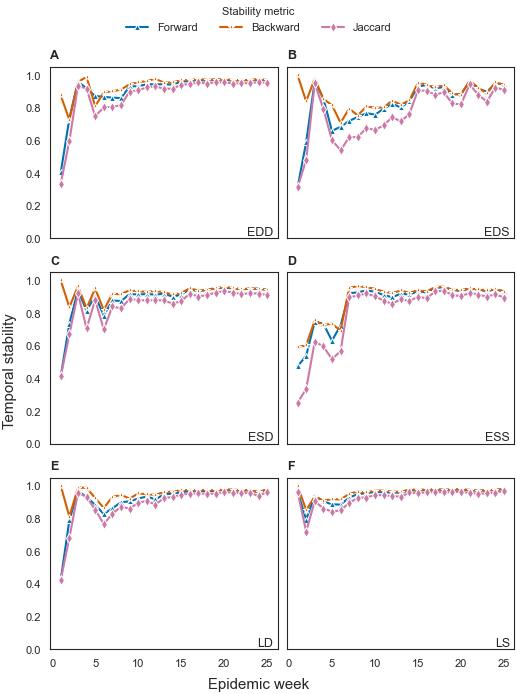

In [41]:
fig4, axes4 = plt.subplots(
    3,
    2,
    figsize=(
        cm_to_inch(PLOS_WIDTHS_CM["text_column"]),
        cm_to_inch(PLOS_WIDTHS_CM["text_column"]) * 1.25,
    ),
    sharex=True,
    sharey=True,
    constrained_layout=True,
    gridspec_kw={"hspace": 0.05},
)
axes4 = axes4.flatten()

for ax,  (m, frame) in zip(axes4, stability_frames.items()):
    plot_stability_panel(frame, ax, m)

handles, labels = axes4[0].get_legend_handles_labels()
for ax in axes4:
    if ax.legend_ is not None:
        ax.legend_.remove()

fig4.legend(
    handles,
    labels,
    title="Stability metric",
    loc="upper center",
    bbox_to_anchor=(0.5, 1.075),
    ncol=3,
)
fig4.supylabel("Temporal stability")
fig4.supxlabel("Epidemic week")
add_panel_labels(list(axes4))
export_figure(fig4, "Fig4")
plt.show()


In [48]:
stability_frames["EDD"][["forward", "backward", "jaccard"]].min()

forward     0.403061
backward    0.725342
jaccard     0.335177
dtype: float64

In [54]:
stability_frames["EDS"][["forward", "backward", "jaccard"]].min()

forward     0.311111
backward    0.707183
jaccard     0.311111
dtype: float64

In [50]:
stability_frames["ESD"][["forward", "backward", "jaccard"]].min()

forward     0.411765
backward    0.817525
jaccard     0.411765
dtype: float64

In [51]:
stability_frames["ESS"][["forward", "backward", "jaccard"]].min()

forward     0.473684
backward    0.591837
jaccard     0.251701
dtype: float64

In [52]:
stability_frames["LD"][["forward", "backward", "jaccard"]].min()

forward     0.424242
backward    0.810277
jaccard     0.424242
dtype: float64

In [53]:
stability_frames["LS"][["forward", "backward", "jaccard"]].min()

forward     0.792754
backward    0.851449
jaccard     0.719302
dtype: float64

## Figure 5 · Boston cluster composition

The final section pairs cluster-size frequencies with exposure composition across
focus clusters. It provides a compact descriptive summary for the empirical case study.


Saved PDF: /Users/ydnkka/Desktop/Phd Project/projects/epilink/evaluation/results/figures/Fig5.pdf
Saved TIFF: /Users/ydnkka/Desktop/Phd Project/projects/epilink/evaluation/results/figures/Fig5.tif


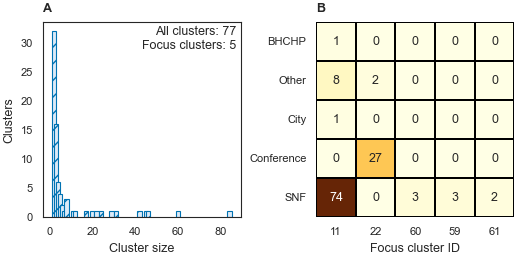

In [11]:
boston_comp = read_result_table("boston", "cluster_composition.parquet")
boston_sizes = read_result_table("boston", "cluster_sizes.parquet")

EXPOSURE_LABELS = {
    "count::BHCHP": "BHCHP",
    "count::Other": "Other",
    "count::City": "City",
    "count::Conference": "Conference",
    "count::SNF": "SNF",
}

available_columns = [column for column in EXPOSURE_LABELS if column in boston_comp.columns]
if not available_columns:
    raise ValueError("No configured exposure columns were found in the Boston results.")

exposure_counts = boston_comp[available_columns].copy().rename(columns=EXPOSURE_LABELS)
exposure_counts.index = boston_comp["cluster_id"].astype(int)
size_counts = boston_sizes["size"].value_counts().sort_index()

fig5, axes5 = plt.subplots(
    1,
    2,
    figsize=(
        cm_to_inch(PLOS_WIDTHS_CM["text_column"]),
        cm_to_inch(PLOS_WIDTHS_CM["text_column"]) * 0.5,
    ),
    constrained_layout=True,
)
axes5 = np.atleast_1d(axes5).flatten()

bars = axes5[0].bar(
    size_counts.index,
    size_counts.values,
    color="#DDEAF7",
    edgecolor="#0072B2",
    linewidth=0.8,
    width=2,
)
for patch in bars:
    patch.set_hatch("//")

axes5[0].set(xlabel="Cluster size", ylabel="Clusters")
axes5[0].text(
    0.98,
    0.98,
    (
        f"All clusters: {len(boston_sizes)}\n"
        f"Focus clusters: {int(boston_sizes['is_focus_cluster'].sum())}"
    ),
    transform=axes5[0].transAxes,
    ha="right",
    va="top",
)

vmax = float(np.nanmax(exposure_counts.to_numpy(dtype=float)))
sns.heatmap(
    exposure_counts.T,
    vmin=0,
    vmax=max(1.0, vmax),
    cmap="YlOrBr",
    annot=True,
    fmt=".0f",
    linewidths=0.01,
    linecolor="black",
    cbar=False,
    ax=axes5[1],
)
axes5[1].tick_params(axis="y", rotation=0)
axes5[1].set_xlabel("Focus cluster ID")
axes5[1].set_ylabel("")

add_panel_labels(list(axes5))
export_figure(fig5, "Fig5")
plt.show()


In [60]:
boston_sizes["size"].describe()

count    77.000000
mean      8.337662
std      14.420937
min       2.000000
25%       2.000000
50%       3.000000
75%       5.000000
max      84.000000
Name: size, dtype: float64

## Notes

- Set `SAVE_FIGURES = False` to preview plots without writing files.
- Re-run the data-loading cells after refreshing any upstream parquet outputs.
- Exports are grouped under `results/figures/`.
